In [166]:
# basic libraries
import pandas as pd
import numpy as np
import seaborn as sns  
import matplotlib.pyplot as plt

%matplotlib inline

In [167]:
## loading the algerian forest fires clean dataset
df = pd.read_csv('../data/clean_algerian_forest_fires_clean_dataset.csv')

In [168]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,1.0,6,2012,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,2.0,6,2012,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,3.0,6,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,4.0,6,2012,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,5.0,6,2012,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [169]:
df.columns

Index(['day', 'month', 'year', 'Temperature', 'RH', 'Ws', 'Rain', 'FFMC',
       'DMC', 'DC', 'ISI', 'BUI', 'FWI', 'Classes', 'Region'],
      dtype='object')

In [170]:
df.drop(['day', 'month', 'year'], axis=1, inplace=True)

In [171]:
df.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [172]:
df['Classes'].value_counts()    

Classes
fire             131
not fire         101
fire               4
fire               2
not fire           2
not fire           1
not fire           1
not fire           1
Name: count, dtype: int64

In [173]:
df['Classes'] = np.where(df['Classes'].str.contains('not fire'), 0, 1)

In [174]:
df['Classes'].value_counts()    

Classes
1    137
0    106
Name: count, dtype: int64

In [175]:
## Independent and dependent features
X = df.drop('FWI', axis=1)
y = df['FWI']

In [176]:
## train test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.25, 
                                                    random_state=42)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((182, 11), (61, 11), (182,), (61,))

In [177]:
## feature selection based on correlation
X_train.corr()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,Classes,Region
Temperature,1.000000,-0.656095,-0.305977,-0.317512,0.694768,0.498173,0.390684,0.629848,0.473609,0.542141,0.254549
RH,-0.656095,1.000000,0.225736,0.241656,-0.653023,-0.414601,-0.236078,-0.717804,-0.362317,-0.456876,-0.394665
Ws,-0.305977,0.225736,1.000000,0.251932,-0.190076,0.000379,0.096576,-0.023558,0.035633,-0.082570,-0.199969
Rain,-0.317512,0.241656,0.251932,1.000000,-0.545491,-0.289754,-0.302341,-0.345707,-0.300964,-0.369357,-0.059022
FFMC,0.694768,-0.653023,-0.190076,-0.545491,1.000000,0.620807,0.524101,0.750799,0.607210,0.781259,0.249514
DMC,0.498173,-0.414601,0.000379,-0.289754,0.620807,1.000000,0.868647,0.685656,0.983175,0.617273,0.212582
DC,0.390684,-0.236078,0.096576,-0.302341,0.524101,0.868647,1.000000,0.513701,0.942414,0.543581,-0.060838
ISI,0.629848,-0.717804,-0.023558,-0.345707,0.750799,0.685656,0.513701,1.000000,0.643818,0.742977,0.296441
BUI,0.473609,-0.362317,0.035633,-0.300964,0.607210,0.983175,0.942414,0.643818,1.000000,0.612239,0.114897
Classes,0.542141,-0.456876,-0.082570,-0.369357,0.781259,0.617273,0.543581,0.742977,0.612239,1.000000,0.188837


<Axes: >

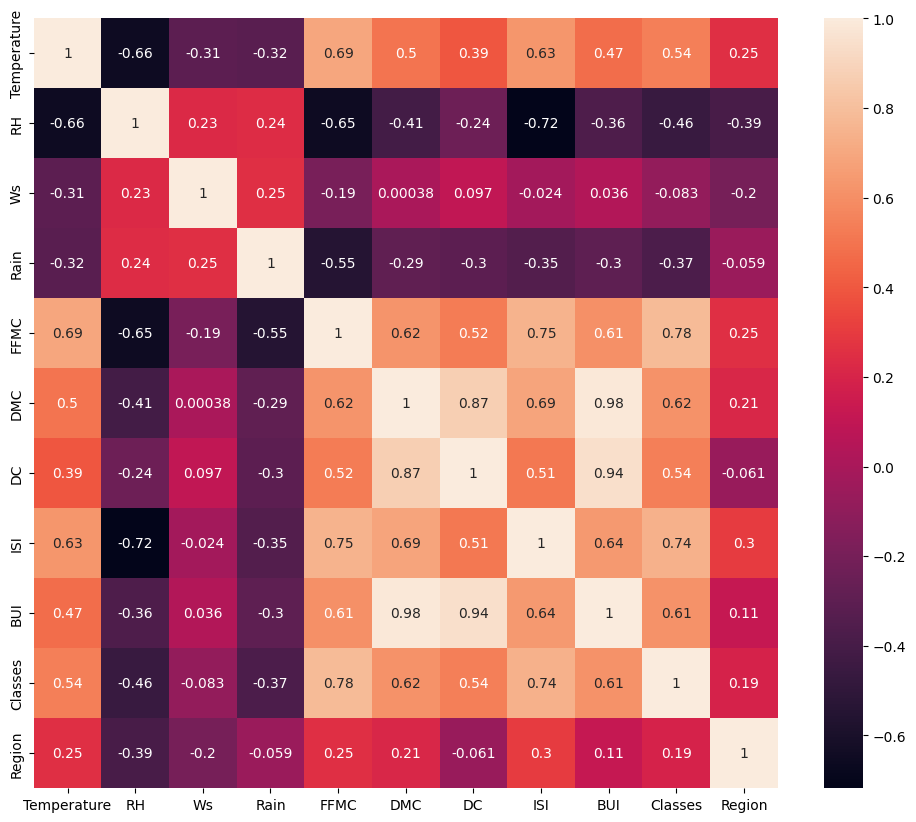

In [178]:
## check for multicollinearity
plt.figure(figsize=(12, 10))
sns.heatmap(X_train.corr(), annot=True)

In [179]:
def correlation(dataset, threshold):
    col_corr = set()  # Set of all the names of deleted columns
    corr_matrix = dataset.corr()
    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i, j]) > threshold:
                colname = corr_matrix.columns[i]  # getting the name of column
                col_corr.add(colname)
    return col_corr

In [180]:
## setting the threshold to 0.85
correlation(X_train, 0.85)

{'BUI', 'DC'}

In [181]:
## drop these features when correlation is greater than 0.85
X_train.drop(['RH', 'DC'], axis=1, inplace=True)
X_test.drop(['RH', 'DC'], axis=1, inplace=True)

X_train.shape, X_test.shape

((182, 9), (61, 9))

### Feature Scaling or Standardization

In [182]:
from sklearn.preprocessing import StandardScaler    
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [183]:
X_train_scaled

array([[-0.84284248,  1.29972026, -0.33727373, ..., -0.77269802,
        -1.10431526, -0.98907071],
       [-0.30175842, -0.59874754, -0.29048728, ..., -0.90344718,
        -1.10431526,  1.01105006],
       [ 2.13311985, -0.21905398, -0.38406017, ...,  0.38339978,
         0.90553851,  1.01105006],
       ...,
       [-1.9250106 ,  0.54033314,  2.984564  , ..., -1.03419633,
        -1.10431526, -0.98907071],
       [ 0.50986767,  0.16063958, -0.38406017, ...,  0.18383528,
         0.90553851,  1.01105006],
       [-0.57230045,  2.05910739,  0.45809587, ..., -0.99290713,
        -1.10431526, -0.98907071]], shape=(182, 9))

### boxplot to understand the effect of feature scaling

Text(0.5, 1.0, 'After Scaling')

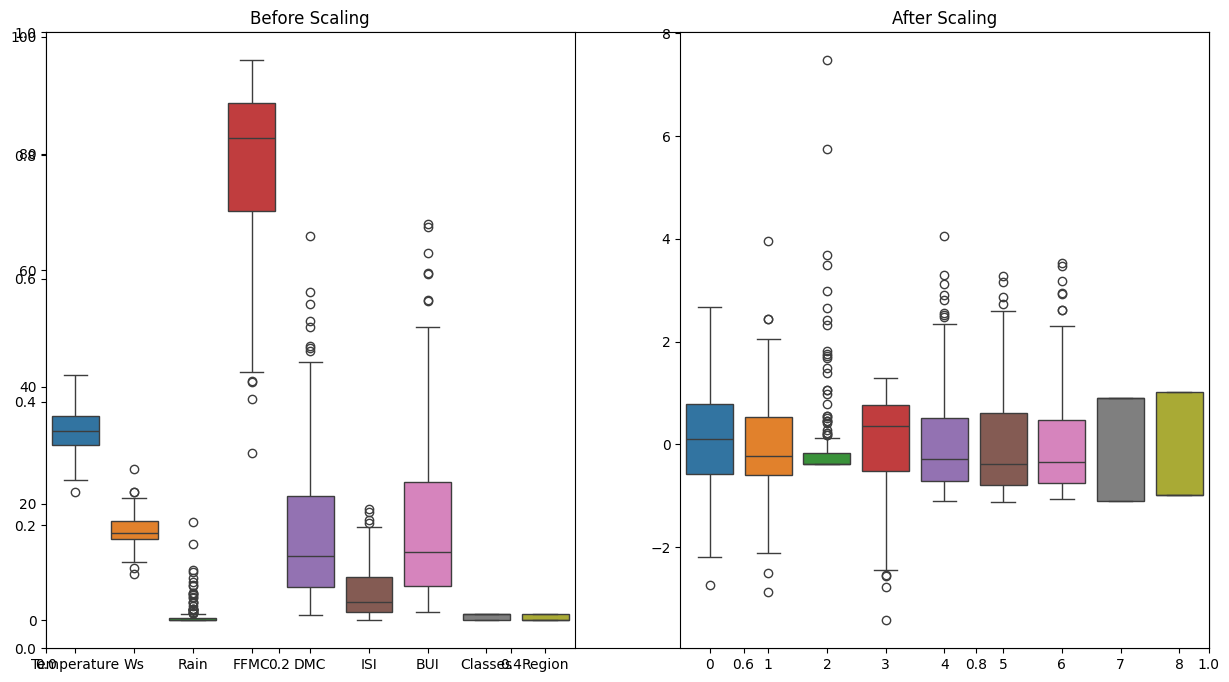

In [184]:
plt.subplots(figsize=(15, 8))
plt.subplot(1, 2, 1)
sns.boxplot(data=X_train)
plt.title('Before Scaling')
plt.subplot(1, 2, 2)
sns.boxplot(data=X_train_scaled)
plt.title('After Scaling')   


### Linear Regression Model


In [185]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

linreg = LinearRegression()
linreg.fit(X_train_scaled, y_train)
y_pred = linreg.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.4919561763513575
R-squared: 0.9888849945231384
Mean Absolute Error: 0.4674211195630491


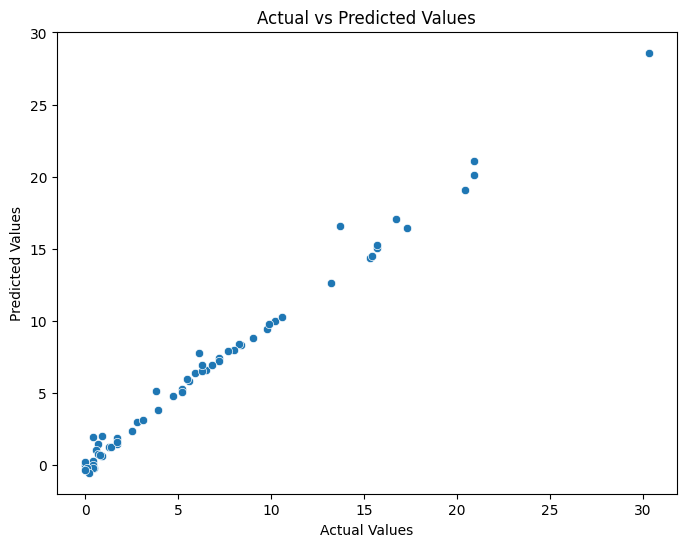

In [186]:
## scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

### Lasso Regression

In [187]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model = Lasso()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 2.000042234314739
R-squared: 0.9548120717718446
Mean Absolute Error: 1.0816271849299948


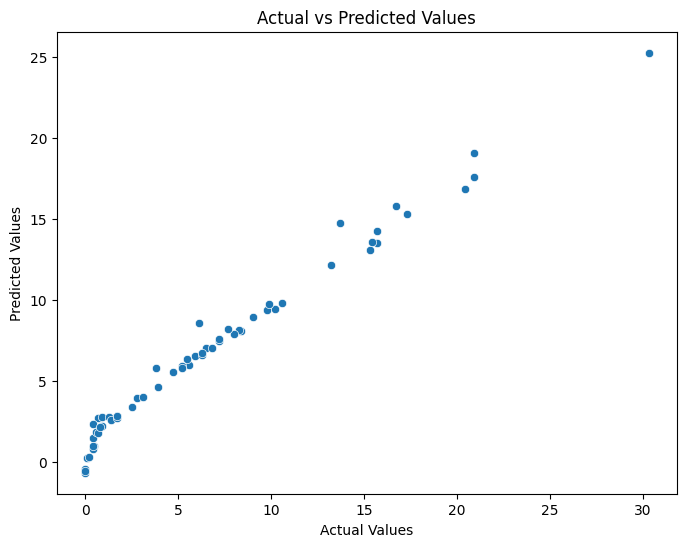

In [188]:
## scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [189]:
## cross validation and hyperparameter tuning
from sklearn.linear_model import LassoCV
lassocv = LassoCV(cv=5)
lassocv.fit(X_train_scaled, y_train)

,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,copy_X,True
,cv,5
,verbose,False
,n_jobs,None


In [190]:
lassocv.predict(X_test_scaled)

array([ 8.22602492e+00,  7.33666868e+00, -3.97422185e-02,  5.38442754e+00,
        6.63287528e+00,  1.59581564e+00,  2.48968548e+00,  7.26975526e+00,
        2.02920301e+00,  3.28127572e+00,  4.00791822e-01,  8.02583721e+00,
        9.44569883e+00,  1.63907999e+01,  1.89284079e+01,  1.55459102e+00,
        1.57987696e+00, -5.77597423e-01,  6.84767534e+00,  3.11440643e+00,
        1.78782960e+00,  2.42140424e-01,  6.27247683e+00,  1.47996644e-02,
        2.09227125e+01,  4.85755321e+00,  5.76199534e+00,  9.90929188e+00,
       -6.23472950e-01,  9.90092135e+00,  6.48610046e+00, -1.82305601e-01,
        1.02566676e+01,  1.49450427e+01,  1.48627664e+00,  9.50672982e-01,
        1.88459638e+00,  5.97048002e+00, -3.82212965e-01, -2.76130340e-01,
        6.82756015e+00,  1.69244373e+00,  8.18992212e+00, -7.76528111e-01,
        1.51570562e+01,  7.92252297e+00,  8.01912743e+00,  9.91095169e-01,
        1.26441609e+01,  9.26008321e-01,  2.83347460e+01,  5.37740960e+00,
        1.71220585e+01,  

In [191]:
print(f'Best alpha value: {lassocv.alpha_}')

Best alpha value: 0.04644041416555538


Best score: 0.987746994199646


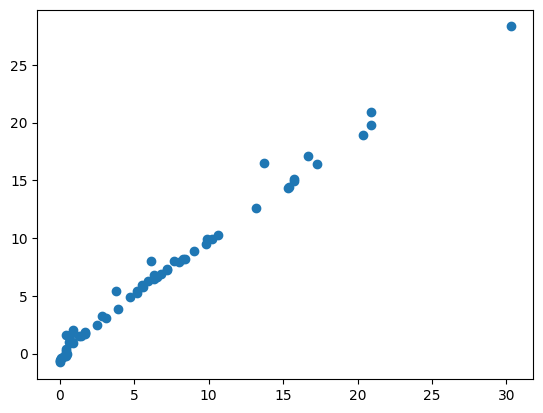

In [192]:
print(f'Best score: {lassocv.score(X_test_scaled, y_test)}')
plt.scatter(x=y_test, y=lassocv.predict(X_test_scaled))

In [193]:
print(f"all tried alphas: {lassocv.alphas_}")

all tried alphas: [7.05853002 6.58280872 6.13914944 5.72539132 5.33951911 4.97965339
 4.64404142 4.33104857 4.03915039 3.76692517 3.51304702 3.27627941
 3.05546914 2.84954075 2.65749124 2.47838523 2.31135036 2.15557308
 2.01029467 1.87480753 1.74845178 1.63061198 1.52071419 1.41822315
 1.32263965 1.23349817 1.15036452 1.0728338  1.00052839 0.93309613
 0.87020857 0.81155943 0.75686304 0.705853   0.65828087 0.61391494
 0.57253913 0.53395191 0.49796534 0.46440414 0.43310486 0.40391504
 0.37669252 0.3513047  0.32762794 0.30554691 0.28495408 0.26574912
 0.24783852 0.23113504 0.21555731 0.20102947 0.18748075 0.17484518
 0.1630612  0.15207142 0.14182231 0.13226397 0.12334982 0.11503645
 0.10728338 0.10005284 0.09330961 0.08702086 0.08115594 0.0756863
 0.0705853  0.06582809 0.06139149 0.05725391 0.05339519 0.04979653
 0.04644041 0.04331049 0.0403915  0.03766925 0.03513047 0.03276279
 0.03055469 0.02849541 0.02657491 0.02478385 0.0231135  0.02155573
 0.02010295 0.01874808 0.01748452 0.01630612 

In [194]:
lassocv.mse_path_

array([[53.64536329, 65.39074075, 54.89628985, 77.90299066, 39.38236846],
       [46.99139716, 59.81506814, 49.29840831, 75.6645852 , 35.31758355],
       [41.14908917, 53.9178721 , 42.49594889, 68.35708298, 31.76996123],
       [36.05788169, 48.41773965, 36.66879347, 61.92819453, 28.67296816],
       [31.62067285, 42.76466229, 31.68391904, 56.26841266, 24.93183295],
       [27.75285367, 37.81922812, 27.42599138, 51.28216115, 21.56888645],
       [24.3807738 , 33.49107651, 23.7950306 , 45.25481907, 18.66094162],
       [21.44052804, 29.70161639, 20.70460191, 39.90418045, 16.14837778],
       [18.876308  , 26.38208059, 18.07969934, 35.23429953, 13.97821475],
       [16.63960395, 23.47341883, 15.85530749, 31.15712074, 12.10483403],
       [14.68819307, 20.92329068, 13.97555108, 27.59649208, 10.48862803],
       [12.98525144, 18.68636627, 12.39173305, 24.48611006,  9.09521221],
       [11.49893734, 16.72312788, 11.06186319, 21.7677198 ,  7.89445038],
       [10.19961097, 14.9991189 ,  9.9

### Ridge Regression

In [195]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

ridge = Ridge()
ridge.fit(X_train_scaled, y_train)  # Fit the Ridge model
y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 0.5148739554703012
R-squared: 0.9883672019784573
Mean Absolute Error: 0.47860538719112106


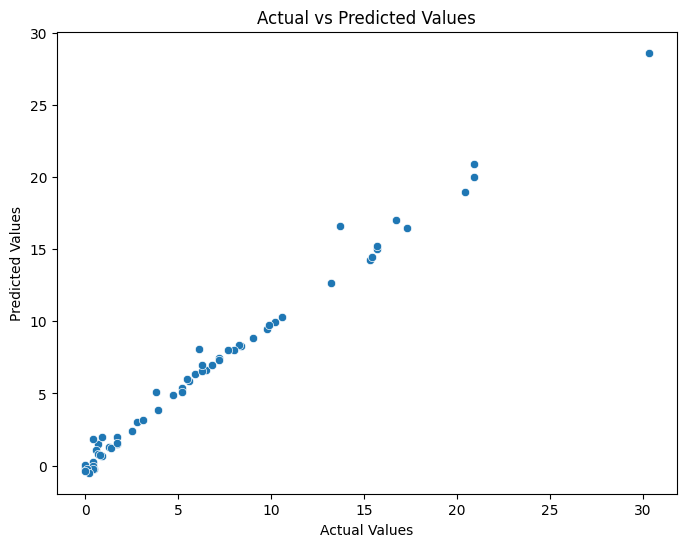

In [196]:
## scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [197]:
from sklearn.linear_model import RidgeCV
ridgecv = RidgeCV(cv=5)
ridgecv.fit(X_train_scaled, y_train)

,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,5
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


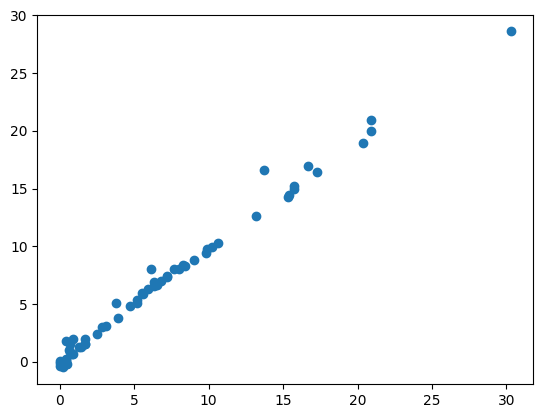

In [198]:
y_pred = ridgecv.predict(X_test_scaled)
plt.scatter(x=y_test, y=y_pred);

In [199]:
mae=mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)
print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {score}')

Mean Absolute Error: 0.47860538719112106
R-squared: 0.9883672019784573


In [200]:
ridgecv.alpha_

np.float64(1.0)

In [201]:
ridgecv.alphas

(0.1, 1.0, 10.0)

In [202]:
ridgecv.get_params()

{'alpha_per_target': False,
 'alphas': (0.1, 1.0, 10.0),
 'cv': 5,
 'fit_intercept': True,
 'gcv_mode': None,
 'scoring': None,
 'store_cv_results': False}

### ElasticNet

In [203]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

model = ElasticNet()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')

Mean Squared Error: 4.304938575689994
R-squared: 0.902736426237745
Mean Absolute Error: 1.6677898565013587


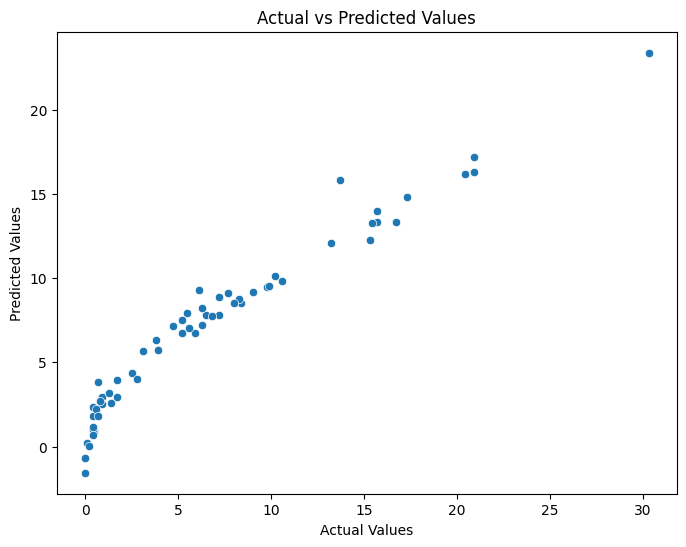

In [204]:
## scatter plot of actual vs predicted values
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.show()

In [205]:
from sklearn.linear_model import ElasticNetCV
elasticcv = ElasticNetCV(cv=5)
elasticcv.fit(X_train_scaled, y_train)

,l1_ratio,0.5
,eps,0.001
,n_alphas,'deprecated'
,alphas,'warn'
,fit_intercept,True
,precompute,'auto'
,max_iter,1000
,tol,0.0001
,cv,5
,copy_X,True
,verbose,0


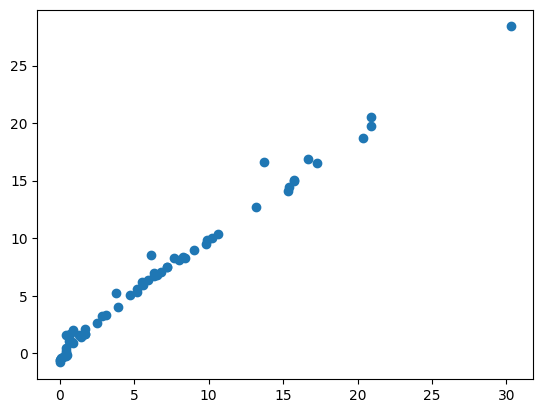

In [206]:
y_pred = elasticcv.predict(X_test_scaled)
plt.scatter(x=y_test, y=y_pred);

In [207]:
mae = mean_absolute_error(y_test, y_pred)
score = r2_score(y_test, y_pred)

print(f'Mean Absolute Error: {mae}')
print(f'R-squared: {score}')

Mean Absolute Error: 0.5578200203137091
R-squared: 0.985664785390548


In [208]:
elasticcv.alpha_

np.float64(0.04311146156383891)

In [209]:
elasticcv.alphas

'warn'

In [210]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [212]:
ridge

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [213]:
import pickle
pickle.dump(scaler, open('scalar.pkl', 'wb'))
pickle.dump(ridge, open('ridge.pkl', 'wb'))

In [ ]:
``